# Trajectory Exploration Story

Notebook nay dung de trinh bay project theo huong `Large-scale GPS Trajectory Processing` tren schema chung `trips_clean` va benchmark window co dinh.


## 1. Imports and Runtime Parameters

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from pyspark.sql import functions as F

WORK_ROOT = Path.cwd().resolve()
if not (WORK_ROOT / "src").exists():
    WORK_ROOT = WORK_ROOT.parent
SRC_DIR = WORK_ROOT / "src"
REFERENCE_DIR = WORK_ROOT / "reference"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from test_read_minio_parquet import build_spark_session
from trajectory_utils import load_trajectory_df, register_supporting_views, register_trajectory_view

SPARK_MASTER = "spark://spark-master:7077"
MINIO_ENDPOINT = "http://minio1:9000"
MINIO_ACCESS_KEY = "minioadmin"
MINIO_SECRET_KEY = "minioadmin"
SOURCE_PATH = "s3a://taxi-data/bench/parquet/raw"
ZONE_LOOKUP_PATH = str(REFERENCE_DIR / "taxi_zone_lookup.csv")
WINDOW_START = "2024-01-01 00:00:00"
WINDOW_END = "2024-02-01 00:00:00"


## 2. Create Spark Session and Load the Window

In [2]:
try:
    spark.stop()
except Exception:
    pass

spark = build_spark_session(
    app_name="trajectory-exploration-story",
    endpoint=MINIO_ENDPOINT,
    access_key=MINIO_ACCESS_KEY,
    secret_key=MINIO_SECRET_KEY,
    master=SPARK_MASTER,
)
spark.sparkContext.setLogLevel("ERROR")

trajectory_df = load_trajectory_df(spark, "parquet", SOURCE_PATH, layout="raw")
trips_clean = register_trajectory_view(spark, trajectory_df)
register_supporting_views(spark, ZONE_LOOKUP_PATH)

window_df = trips_clean.filter(
    (F.col("pickup_ts") >= F.to_timestamp(F.lit(WINDOW_START)))
    & (F.col("pickup_ts") < F.to_timestamp(F.lit(WINDOW_END)))
)
print("Window row count:", window_df.count())


:: loading settings :: url = jar:file:/usr/local/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/jovyan/.ivy2/cache
The jars for the packages stored in: /home/jovyan/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
software.amazon.awssdk#bundle added as a dependency
org.apache.spark#spark-avro_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-56a2bbcb-62cc-4671-a334-d0813f6ed197;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.4.1 in central
	found software.amazon.awssdk#bundle;2.24.6 in central
	found org.wildfly.openssl#wildfly-openssl;1.1.3.Final in central
	found org.apache.spark#spark-avro_2.13;4.0.1 in central
	found org.scala-lang.modules#scala-parallel-collections_2.13;1.2.0 in central
	found org.tukaani#xz;1.10 in central
:: resolution report :: resolve 229ms :: artifacts dl 4ms
	:: modules in use:
	org.apache.hadoop#hadoop-aw

Window row count: 2964606


## 3. Daily trip activity

,trip_date,trip_count
0,2024-01-01,81013
1,2024-01-02,75519
2,2024-01-03,82427
3,2024-01-04,102901
4,2024-01-05,103178


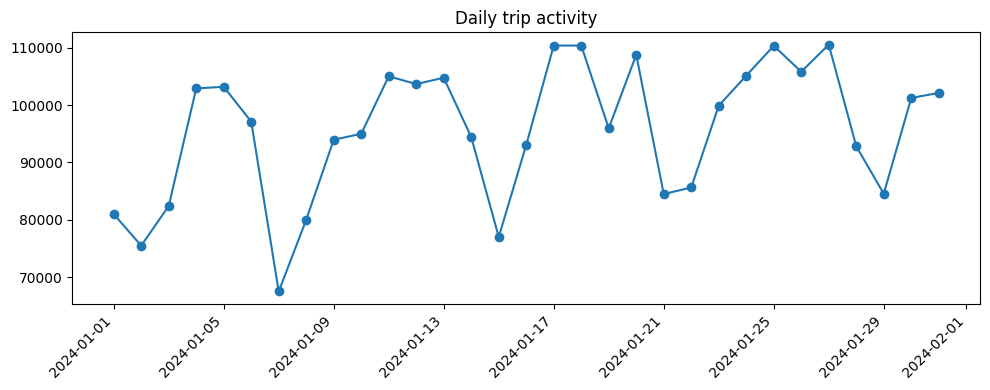

In [3]:
daily_pdf = (
    window_df.groupBy("trip_date")
    .agg(F.count("*").alias("trip_count"))
    .orderBy("trip_date")
    .toPandas()
)
display(daily_pdf.head())

plt.figure(figsize=(10, 4))
plt.plot(daily_pdf["trip_date"], daily_pdf["trip_count"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.title("Daily trip activity")
plt.tight_layout()
plt.show()


## 4. Top origin zones with spatial labels

,origin_zone_id,borough,zone,service_zone,trip_count,origin_label
0,132,Queens,JFK Airport,Airports,145240,JFK Airport (Queens)
1,161,Manhattan,Midtown Center,Yellow Zone,143469,Midtown Center (Manhattan)
2,237,Manhattan,Upper East Side South,Yellow Zone,142707,Upper East Side South (Manhattan)
3,236,Manhattan,Upper East Side North,Yellow Zone,136464,Upper East Side North (Manhattan)
4,162,Manhattan,Midtown East,Yellow Zone,106717,Midtown East (Manhattan)
5,230,Manhattan,Times Sq/Theatre District,Yellow Zone,106324,Times Sq/Theatre District (Manhattan)
6,186,Manhattan,Penn Station/Madison Sq West,Yellow Zone,104522,Penn Station/Madison Sq West (Manhattan)
7,142,Manhattan,Lincoln Square East,Yellow Zone,104080,Lincoln Square East (Manhattan)
8,138,Queens,LaGuardia Airport,Airports,89530,LaGuardia Airport (Queens)
9,239,Manhattan,Upper West Side South,Yellow Zone,88474,Upper West Side South (Manhattan)


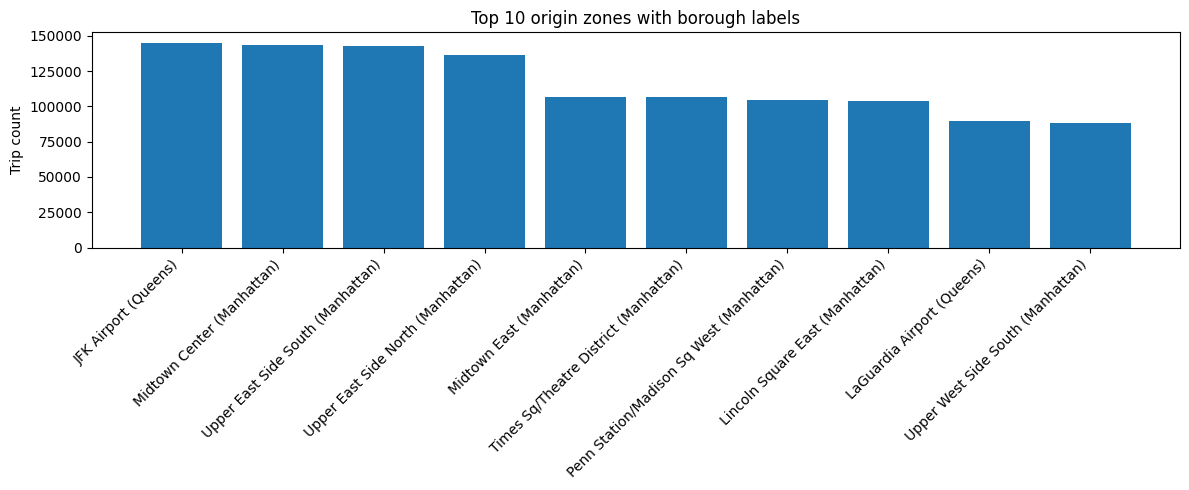

In [4]:
origin_pdf = spark.sql(
    f"""
    SELECT
        t.origin_zone_id,
        z.borough,
        z.zone,
        z.service_zone,
        COUNT(*) AS trip_count
    FROM trips_clean t
    JOIN taxi_zone_dim z
      ON t.origin_zone_id = z.location_id
    WHERE t.pickup_ts >= TIMESTAMP '{WINDOW_START}'
      AND t.pickup_ts < TIMESTAMP '{WINDOW_END}'
      AND t.origin_zone_id IS NOT NULL
    GROUP BY t.origin_zone_id, z.borough, z.zone, z.service_zone
    ORDER BY trip_count DESC
    LIMIT 10
    """
).toPandas()
origin_pdf["origin_label"] = origin_pdf["zone"] + " (" + origin_pdf["borough"] + ")"
display(origin_pdf)

plt.figure(figsize=(12, 5))
plt.bar(origin_pdf["origin_label"], origin_pdf["trip_count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 origin zones with borough labels")
plt.ylabel("Trip count")
plt.tight_layout()
plt.show()


## 5. Top routes by volume with origin-destination labels

,route_key,origin_borough,origin_zone,destination_borough,destination_zone,trip_count,avg_total_amt,avg_trip_distance,route_label
0,237->236,Manhattan,Upper East Side South,Manhattan,Upper East Side North,21883,15.508877,1.058019,Upper East Side South -> Upper East Side North
1,236->237,Manhattan,Upper East Side North,Manhattan,Upper East Side South,19402,15.878771,1.044600,Upper East Side North -> Upper East Side South
2,236->236,Manhattan,Upper East Side North,Manhattan,Upper East Side North,15955,13.050416,0.623932,Upper East Side North -> Upper East Side North
3,237->237,Manhattan,Upper East Side South,Manhattan,Upper East Side South,14938,13.529931,0.621655,Upper East Side South -> Upper East Side South
4,161->237,Manhattan,Midtown Center,Manhattan,Upper East Side South,10275,16.735615,1.074143,Midtown Center -> Upper East Side South
5,142->239,Manhattan,Lincoln Square East,Manhattan,Upper West Side South,8980,14.691315,0.985276,Lincoln Square East -> Upper West Side South
6,237->161,Manhattan,Upper East Side South,Manhattan,Midtown Center,8834,16.197359,1.055986,Upper East Side South -> Midtown Center
7,161->236,Manhattan,Midtown Center,Manhattan,Upper East Side North,8766,21.588192,1.945183,Midtown Center -> Upper East Side North
8,239->142,Manhattan,Upper West Side South,Manhattan,Lincoln Square East,8675,14.330707,0.879890,Upper West Side South -> Lincoln Square East
9,239->238,Manhattan,Upper West Side South,Manhattan,Upper West Side North,8445,13.602470,0.833905,Upper West Side South -> Upper West Side North


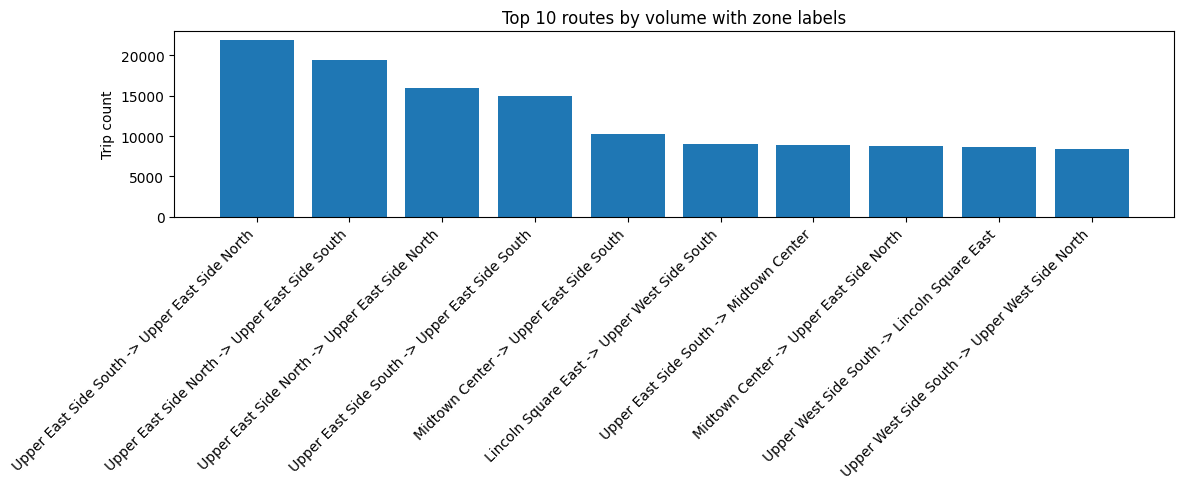

In [5]:
route_pdf = spark.sql(
    f"""
    SELECT
        t.route_key,
        oz.borough AS origin_borough,
        oz.zone AS origin_zone,
        dz.borough AS destination_borough,
        dz.zone AS destination_zone,
        COUNT(*) AS trip_count,
        AVG(t.total_amt) AS avg_total_amt,
        AVG(t.trip_distance) AS avg_trip_distance
    FROM trips_clean t
    JOIN taxi_zone_dim oz
      ON t.origin_zone_id = oz.location_id
    JOIN taxi_zone_dim dz
      ON t.destination_zone_id = dz.location_id
    WHERE t.pickup_ts >= TIMESTAMP '{WINDOW_START}'
      AND t.pickup_ts < TIMESTAMP '{WINDOW_END}'
      AND t.route_key IS NOT NULL
    GROUP BY t.route_key, oz.borough, oz.zone, dz.borough, dz.zone
    ORDER BY trip_count DESC
    LIMIT 10
    """
).toPandas()
route_pdf["route_label"] = route_pdf["origin_zone"] + " -> " + route_pdf["destination_zone"]
display(route_pdf)

plt.figure(figsize=(12, 5))
plt.bar(route_pdf["route_label"], route_pdf["trip_count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 routes by volume with zone labels")
plt.ylabel("Trip count")
plt.tight_layout()
plt.show()
